# EfficientNet-B0 v2 - Improved Training Experiment

This notebook is a second EfficientNet-B0 experiment for the TwinCar project.

The goal is to improve the previous EfficientNet-B0 baseline.

Main changes compared to the first EfficientNet-B0 run:

1. **Larger image size:** `260` instead of `224`
2. **More conservative crop:** `scale=(0.90, 1.00)` so important car details are less likely to be cropped out
3. **Longer training window:** `45` epochs with early stopping
4. **More patience:** `8` epochs before stopping
5. **Higher dropout:** `0.4`
6. **Differential learning rates**

Why this makes sense for TwinCar:

Vehicle make/model classification is a fine-grained image classification problem. Many classes are visually similar, so small details such as headlights, grille shape, rear lights, and body shape matter.

In [ ]:
!pip install -q datasets scikit-learn tqdm

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 1. Imports and Configuration

`/content/twincar_data` is local Colab storage. It is faster than reading images directly from Google Drive.

The trained model and artifacts are saved permanently to:

`/content/drive/MyDrive/twincar/models/efficientnet_b0_v2/`

In [ ]:
import os
import json
import time
import shutil
import random
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, WeightedRandomSampler
from torchvision import datasets, transforms, models
from torchvision.models import EfficientNet_B0_Weights

from datasets import load_dataset
from tqdm.auto import tqdm

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
)

# Project paths

PROJECT_DIR = Path('/content/drive/MyDrive/twincar')
DATA_DIR = Path('/content/twincar_data')
METADATA_PATH = PROJECT_DIR / 'data' / 'stanford_metadata.csv'
STANFORD_CACHE = PROJECT_DIR / 'stanford_cars_cache'

MODEL_NAME = 'efficientnet_b0_v2'
MODEL_DIR = PROJECT_DIR / 'models' / MODEL_NAME
MODEL_DIR.mkdir(parents=True, exist_ok=True)

# Experiment hyperparameters

SEED = 42
IMG_SIZE = 260
BATCH_SIZE = 32
NUM_WORKERS = 2

EPOCHS = 45
PATIENCE = 8
LR_PATIENCE = 3

BACKBONE_LR = 1e-4
HEAD_LR = 3e-4
WEIGHT_DECAY = 1e-4
DROPOUT = 0.4
LABEL_SMOOTHING = 0.1

TRAIN_CROP_SCALE = (0.90, 1.00)
TOP_K = 5

FORCE_REBUILD_DATA = False

# Reproducibility

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.benchmark = True

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print('PROJECT_DIR:', PROJECT_DIR)
print('DATA_DIR:', DATA_DIR)
print('MODEL_DIR:', MODEL_DIR)
print('METADATA_PATH exists:', METADATA_PATH.exists())
print('DEVICE:', DEVICE)


PROJECT_DIR: /content/drive/MyDrive/twincar
DATA_DIR: /content/twincar_data
MODEL_DIR: /content/drive/MyDrive/twincar/models/efficientnet_b0_v2
METADATA_PATH exists: True
DEVICE: cuda


## 2. Prepare ImageFolder Data

PyTorch `ImageFolder` expects this folder structure:

```text
train/
  Audi_S4_Sedan_2012/
    image1.jpg
  BMW_X5_SUV_2007/
    image2.jpg
val/
  ...
test/
  ...
```

If the folders are missing from `/content`, this notebook recreates them from the Hugging Face Stanford Cars dataset and the metadata file produced earlier.

In [ ]:
metadata = pd.read_csv(METADATA_PATH)

print('Metadata rows:', len(metadata))
print('Metadata columns:', list(metadata.columns))
print(metadata['split'].value_counts())

train_df = metadata[metadata['split'] == 'train'].reset_index(drop=True)
val_df = metadata[metadata['split'] == 'val'].reset_index(drop=True)
test_df = metadata[metadata['split'] == 'test'].reset_index(drop=True)

# Leakage check for train/val because both are derived from Hugging Face train split.
train_ids = set(train_df['hf_idx'].astype(int))
val_ids = set(val_df['hf_idx'].astype(int))
overlap = train_ids.intersection(val_ids)
print('Train/val overlap:', len(overlap))
assert len(overlap) == 0, 'Data leakage: same Hugging Face train image appears in both train and val!'

Metadata rows: 16103
Metadata columns: ['hf_idx', 'label', 'car_name', 'source_split', 'class_id', 'split', 'original_label', 'class_name', 'make', 'model', 'make_model', 'year']
split
test     8000
train    6887
val      1216
Name: count, dtype: int64
Train/val overlap: 0


In [ ]:
IMG_EXTENSIONS = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}

def sanitize(name):
    return str(name).replace(' ', '_').replace('/', '-')


def get_class_name(row):
    if 'class_name' in row and pd.notna(row['class_name']):
        return row['class_name']
    return row['car_name']


def count_images(split_name):
    split_dir = DATA_DIR / split_name
    if not split_dir.exists():
        return 0
    return sum(
        1 for p in split_dir.rglob('*')
        if p.suffix.lower() in IMG_EXTENSIONS
    )


def reset_split_dirs():
    for split_name in ['train', 'val', 'test']:
        split_dir = DATA_DIR / split_name
        if split_dir.exists():
            shutil.rmtree(split_dir)
        split_dir.mkdir(parents=True, exist_ok=True)
    print('Old train/val/test folders cleared.')


def copy_split(dataset_hf, df_split, split_name):
    split_dir = DATA_DIR / split_name
    copied = 0

    for _, row in tqdm(df_split.iterrows(), total=len(df_split), desc=f'Copying {split_name}'):
        class_name = get_class_name(row)
        class_dir = split_dir / sanitize(class_name)
        class_dir.mkdir(parents=True, exist_ok=True)

        hf_idx = int(row['hf_idx'])
        out_path = class_dir / f'{hf_idx}.jpg'

        img = dataset_hf[hf_idx]['image_path']
        img.save(out_path)
        copied += 1

    print(f'{split_name}: {copied} images copied')


expected_counts = {
    'train': len(train_df),
    'val': len(val_df),
    'test': len(test_df),
}

current_counts = {split: count_images(split) for split in ['train', 'val', 'test']}
print('Current local image counts:', current_counts)
print('Expected image counts:', expected_counts)

needs_rebuild = FORCE_REBUILD_DATA or any(current_counts[s] != expected_counts[s] for s in expected_counts)

if needs_rebuild:
    print('Rebuilding local ImageFolder data in /content...')
    reset_split_dirs()
    dataset = load_dataset('naufalso/stanford_cars', cache_dir=STANFORD_CACHE)

    copy_split(dataset['train'], train_df, 'train')
    copy_split(dataset['train'], val_df, 'val')
    copy_split(dataset['test'], test_df, 'test')

    del dataset
else:
    print('Local ImageFolder data already exists with expected counts. Skipping rebuild.')

final_counts = {split: count_images(split) for split in ['train', 'val', 'test']}
print('Final local image counts:', final_counts)

Current local image counts: {'train': 0, 'val': 0, 'test': 0}
Expected image counts: {'train': 6887, 'val': 1216, 'test': 8000}
Rebuilding local ImageFolder data in /content...
Old train/val/test folders cleared.


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/614 [00:00<?, ?B/s]

Copying train:   0%|          | 0/6887 [00:00<?, ?it/s]

train: 6887 images copied


Copying val:   0%|          | 0/1216 [00:00<?, ?it/s]

val: 1216 images copied


Copying test:   0%|          | 0/8000 [00:00<?, ?it/s]

test: 8000 images copied
Final local image counts: {'train': 6887, 'val': 1216, 'test': 8000}


In [ ]:
EXPECTED_CLASSES = metadata['class_name'].nunique() if 'class_name' in metadata.columns else metadata['car_name'].nunique()

for split in ['train', 'val', 'test']:
    split_path = DATA_DIR / split
    class_dirs = [p for p in split_path.iterdir() if p.is_dir()]
    total_imgs = count_images(split)

    print(f'{split}: {len(class_dirs)} classes, {total_imgs} images')
    assert len(class_dirs) == EXPECTED_CLASSES, f'{split} should have {EXPECTED_CLASSES} class folders.'
    assert total_imgs == expected_counts[split], f'{split} image count mismatch.'

train: 195 classes, 6887 images
val: 195 classes, 1216 images
test: 195 classes, 8000 images


## 3. Image Preprocessing and Augmentation

The key change here is the larger image size and the more conservative crop.

Why conservative crop?

For fine-grained car classification, small details matter. If augmentation crops too aggressively, the model can lose important features such as the grille, headlights, or rear lights.

In [ ]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_transforms = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE, scale=TRAIN_CROP_SCALE),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(8),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.1,
        hue=0.02,
    ),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

val_test_transforms = transforms.Compose([
    transforms.Resize(int(IMG_SIZE * 1.15)),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

print('Train transform:', train_transforms)
print('Val/test transform:', val_test_transforms)

Train transform: Compose(
    RandomResizedCrop(size=(260, 260), scale=(0.9, 1.0), ratio=(0.75, 1.3333), interpolation=bilinear, antialias=True)
    RandomHorizontalFlip(p=0.5)
    RandomRotation(degrees=[-8.0, 8.0], interpolation=nearest, expand=False, fill=0)
    ColorJitter(brightness=(0.8, 1.2), contrast=(0.8, 1.2), saturation=(0.9, 1.1), hue=(-0.02, 0.02))
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)
Val/test transform: Compose(
    Resize(size=299, interpolation=bilinear, max_size=None, antialias=True)
    CenterCrop(size=(260, 260))
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)


## 4. Build Datasets and DataLoaders

We use `WeightedRandomSampler` to reduce class imbalance during training. This helps because some car classes have fewer images than others.

In [ ]:
train_dataset = datasets.ImageFolder(DATA_DIR / 'train', transform=train_transforms)
val_dataset = datasets.ImageFolder(DATA_DIR / 'val', transform=val_test_transforms)
test_dataset = datasets.ImageFolder(DATA_DIR / 'test', transform=val_test_transforms)

assert train_dataset.class_to_idx == val_dataset.class_to_idx, 'Train/val class mapping mismatch!'
assert train_dataset.class_to_idx == test_dataset.class_to_idx, 'Train/test class mapping mismatch!'

NUM_CLASSES = len(train_dataset.classes)
print('Number of classes:', NUM_CLASSES)
print('Train images:', len(train_dataset))
print('Val images:', len(val_dataset))
print('Test images:', len(test_dataset))

# Save both directions of the label mapping. This is important for inference later.
class_to_idx = train_dataset.class_to_idx
idx_to_class = {idx: class_name for class_name, idx in class_to_idx.items()}

with open(MODEL_DIR / 'class_to_idx.json', 'w') as f:
    json.dump(class_to_idx, f, indent=4)

with open(MODEL_DIR / 'idx_to_class.json', 'w') as f:
    json.dump(idx_to_class, f, indent=4)

print('Saved class_to_idx.json and idx_to_class.json to:', MODEL_DIR)

Number of classes: 195
Train images: 6887
Val images: 1216
Test images: 8000
Saved class_to_idx.json and idx_to_class.json to: /content/drive/MyDrive/twincar/models/efficientnet_b0_v2


In [ ]:
targets = train_dataset.targets
class_counts = Counter(targets)
class_weights = {class_id: 1.0 / count for class_id, count in class_counts.items()}
sample_weights = [class_weights[target] for target in targets]

sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True,
)

num_workers = NUM_WORKERS
pin_memory = DEVICE.type == 'cuda'

loader_kwargs = {
    'num_workers': num_workers,
    'pin_memory': pin_memory,
}
if num_workers > 0:
    loader_kwargs['persistent_workers'] = True

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    sampler=sampler,
    **loader_kwargs,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    **loader_kwargs,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    **loader_kwargs,
)

print('Train batches:', len(train_loader))
print('Val batches:', len(val_loader))
print('Test batches:', len(test_loader))
print('NUM_WORKERS:', num_workers)

Train batches: 216
Val batches: 38
Test batches: 250
NUM_WORKERS: 2


## 5. Build EfficientNet-B0 v2

This model is still EfficientNet-B0, but the classifier head is changed for our 195 car classes.

The key improvement is **differential learning rates**:

- backbone learning rate: `1e-4`
- classifier head learning rate: `3e-4`

Simple explanation:

The backbone already learned useful visual features from ImageNet, so we update it more carefully. The classifier head is new, so it needs to learn faster.

In [ ]:
model = models.efficientnet_b0(weights=EfficientNet_B0_Weights.IMAGENET1K_V1)

in_features = model.classifier[1].in_features
model.classifier = nn.Sequential(
    nn.Dropout(p=DROPOUT, inplace=True),
    nn.Linear(in_features, NUM_CLASSES),
)

model = model.to(DEVICE)

trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in model.parameters())
print(f'Trainable params: {trainable_params:,} / {total_params:,}')
print(f'Model size estimate: {total_params * 4 / 1e6:.1f} MB as float32 parameters')

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 144MB/s]


Trainable params: 4,257,343 / 4,257,343
Model size estimate: 17.0 MB as float32 parameters


In [ ]:
# Separate pretrained backbone parameters from the new classifier head.
backbone_params = []
head_params = []

for name, param in model.named_parameters():
    if name.startswith('classifier'):
        head_params.append(param)
    else:
        backbone_params.append(param)

optimizer = torch.optim.AdamW(
    [
        {'params': backbone_params, 'lr': BACKBONE_LR},
        {'params': head_params, 'lr': HEAD_LR},
    ],
    weight_decay=WEIGHT_DECAY,
)

criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=LR_PATIENCE,
)

scaler = torch.amp.GradScaler('cuda', enabled=(DEVICE.type == 'cuda'))

print('Optimizer param groups:')
print('  backbone LR:', optimizer.param_groups[0]['lr'])
print('  head LR    :', optimizer.param_groups[1]['lr'])

Optimizer param groups:
  backbone LR: 0.0001
  head LR    : 0.0003


In [ ]:
train_config = {
    'model': MODEL_NAME,
    'base_architecture': 'efficientnet_b0',
    'num_classes': NUM_CLASSES,
    'img_size': IMG_SIZE,
    'batch_size': BATCH_SIZE,
    'seed': SEED,
    'epochs': EPOCHS,
    'patience': PATIENCE,
    'lr_patience': LR_PATIENCE,
    'backbone_lr': BACKBONE_LR,
    'head_lr': HEAD_LR,
    'weight_decay': WEIGHT_DECAY,
    'dropout': DROPOUT,
    'label_smoothing': LABEL_SMOOTHING,
    'train_crop_scale': list(TRAIN_CROP_SCALE),
    'imagenet_mean': IMAGENET_MEAN,
    'imagenet_std': IMAGENET_STD,
}

with open(MODEL_DIR / 'train_config.json', 'w') as f:
    json.dump(train_config, f, indent=4)

print('Saved train_config.json to:', MODEL_DIR / 'train_config.json')

Saved train_config.json to: /content/drive/MyDrive/twincar/models/efficientnet_b0_v2/train_config.json


## 6. Training Helpers

We track:

- training loss
- validation loss
- validation top-1 accuracy
- validation top-5 accuracy

Top-5 is useful because similar car models may confuse the model. If the correct class is often in top-5, the model is close but still struggles with fine details.

In [ ]:
def topk_correct_count(logits, labels, k=5):
    k = min(k, logits.size(1))
    topk = logits.topk(k, dim=1).indices
    return (topk == labels.unsqueeze(1)).any(dim=1).sum().item()


def run_epoch(model, loader, criterion, optimizer=None, scaler=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    total_loss = 0.0
    correct_top1 = 0
    correct_top5 = 0
    n_seen = 0

    loop_name = 'train' if is_train else 'val'

    with torch.set_grad_enabled(is_train):
        for images, labels in tqdm(loader, desc=loop_name, leave=False):
            images = images.to(DEVICE, non_blocking=True)
            labels = labels.to(DEVICE, non_blocking=True)

            if is_train:
                optimizer.zero_grad(set_to_none=True)

            with torch.amp.autocast('cuda', enabled=(DEVICE.type == 'cuda')):
                logits = model(images)
                loss = criterion(logits, labels)

            if is_train:
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()

            batch_size = labels.size(0)
            total_loss += loss.item() * batch_size
            n_seen += batch_size

            preds = logits.argmax(dim=1)
            correct_top1 += (preds == labels).sum().item()
            correct_top5 += topk_correct_count(logits, labels, k=5)

    return total_loss / n_seen, correct_top1 / n_seen, correct_top5 / n_seen


def save_checkpoint(path, epoch, model, optimizer, scheduler, history, best_val_loss):
    torch.save(
        {
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict(),
            'history': history,
            'best_val_loss': best_val_loss,
            'config': train_config,
        },
        path,
    )

## 7. Train EfficientNet-B0 v2

The best model is selected using **validation loss**, not test accuracy.

This is important because the test set should be used only for final evaluation.

In [ ]:
history = {
    'train_loss': [],
    'val_loss': [],
    'train_top1': [],
    'val_top1': [],
    'val_top5': [],
    'backbone_lr': [],
    'head_lr': [],
}

best_val_loss = float('inf')
best_ckpt_path = MODEL_DIR / 'best_model.pt'
wait = 0

print('=' * 80)
print('TRAINING EfficientNet-B0 v2')
print('=' * 80)
print('Image size:', IMG_SIZE)
print('Backbone LR:', BACKBONE_LR)
print('Head LR:', HEAD_LR)
print('Dropout:', DROPOUT)
print('Crop scale:', TRAIN_CROP_SCALE)

for epoch in range(1, EPOCHS + 1):
    start_time = time.time()

    train_loss, train_top1, _ = run_epoch(model, train_loader, criterion, optimizer, scaler)
    val_loss, val_top1, val_top5 = run_epoch(model, val_loader, criterion)

    scheduler.step(val_loss)

    current_backbone_lr = optimizer.param_groups[0]['lr']
    current_head_lr = optimizer.param_groups[1]['lr']

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_top1'].append(train_top1)
    history['val_top1'].append(val_top1)
    history['val_top5'].append(val_top5)
    history['backbone_lr'].append(current_backbone_lr)
    history['head_lr'].append(current_head_lr)

    elapsed = time.time() - start_time

    print(
        f'Epoch {epoch:02d}/{EPOCHS} '
        f'| train_loss {train_loss:.4f} '
        f'| val_loss {val_loss:.4f} '
        f'| train_top1 {train_top1:.3f} '
        f'| val_top1 {val_top1:.3f} '
        f'| val_top5 {val_top5:.3f} '
        f'| backbone_lr {current_backbone_lr:.2e} '
        f'| head_lr {current_head_lr:.2e} '
        f'| {elapsed:.0f}s'
    )

    save_checkpoint(MODEL_DIR / 'last_checkpoint.pt', epoch, model, optimizer, scheduler, history, best_val_loss)

    if val_loss < best_val_loss - 1e-4:
        best_val_loss = val_loss
        wait = 0
        torch.save(model.state_dict(), best_ckpt_path)
        print(f'  -> val loss improved to {best_val_loss:.4f}; saved best_model.pt')
    else:
        wait += 1
        print(f'  -> no improvement ({wait}/{PATIENCE})')
        if wait >= PATIENCE:
            print(f'\nEarly stopping at epoch {epoch}.')
            break

history_df = pd.DataFrame(history)
history_df.insert(0, 'epoch', range(1, len(history_df) + 1))
history_df.to_csv(MODEL_DIR / 'training_history.csv', index=False)

best_idx = int(np.argmin(history['val_loss']))
print('\nTraining complete.')
print(f'Best epoch    : {best_idx + 1}')
print(f'Best val loss : {history["val_loss"][best_idx]:.4f}')
print(f'Best val top1 : {history["val_top1"][best_idx] * 100:.2f}%')
print(f'Best val top5 : {history["val_top5"][best_idx] * 100:.2f}%')
print('Saved history to:', MODEL_DIR / 'training_history.csv')

TRAINING EfficientNet-B0 v2
Image size: 260
Backbone LR: 0.0001
Head LR: 0.0003
Dropout: 0.4
Crop scale: (0.9, 1.0)


train:   0%|          | 0/216 [00:00<?, ?it/s]

val:   0%|          | 0/38 [00:00<?, ?it/s]

Epoch 01/45 | train_loss 4.9405 | val_loss 4.4451 | train_top1 0.085 | val_top1 0.148 | val_top5 0.391 | backbone_lr 1.00e-04 | head_lr 3.00e-04 | 240s
  -> val loss improved to 4.4451; saved best_model.pt


train:   0%|          | 0/216 [00:00<?, ?it/s]

...

val:   0%|          | 0/38 [00:00<?, ?it/s]

Epoch 44/45 | train_loss 0.9364 | val_loss 1.6666 | train_top1 0.998 | val_top1 0.803 | val_top5 0.948 | backbone_lr 5.00e-05 | head_lr 1.50e-04 | 117s
  -> no improvement (2/8)


train:   0%|          | 0/216 [00:00<?, ?it/s]

val:   0%|          | 0/38 [00:00<?, ?it/s]

Epoch 45/45 | train_loss 0.9365 | val_loss 1.6698 | train_top1 0.999 | val_top1 0.807 | val_top5 0.950 | backbone_lr 5.00e-05 | head_lr 1.50e-04 | 117s
  -> no improvement (3/8)

Training complete.
Best epoch    : 42
Best val loss : 1.6580
Best val top1 : 80.51%
Best val top5 : 95.15%
Saved history to: /content/drive/MyDrive/twincar/models/efficientnet_b0_v2/training_history.csv


## 8. Training Curves

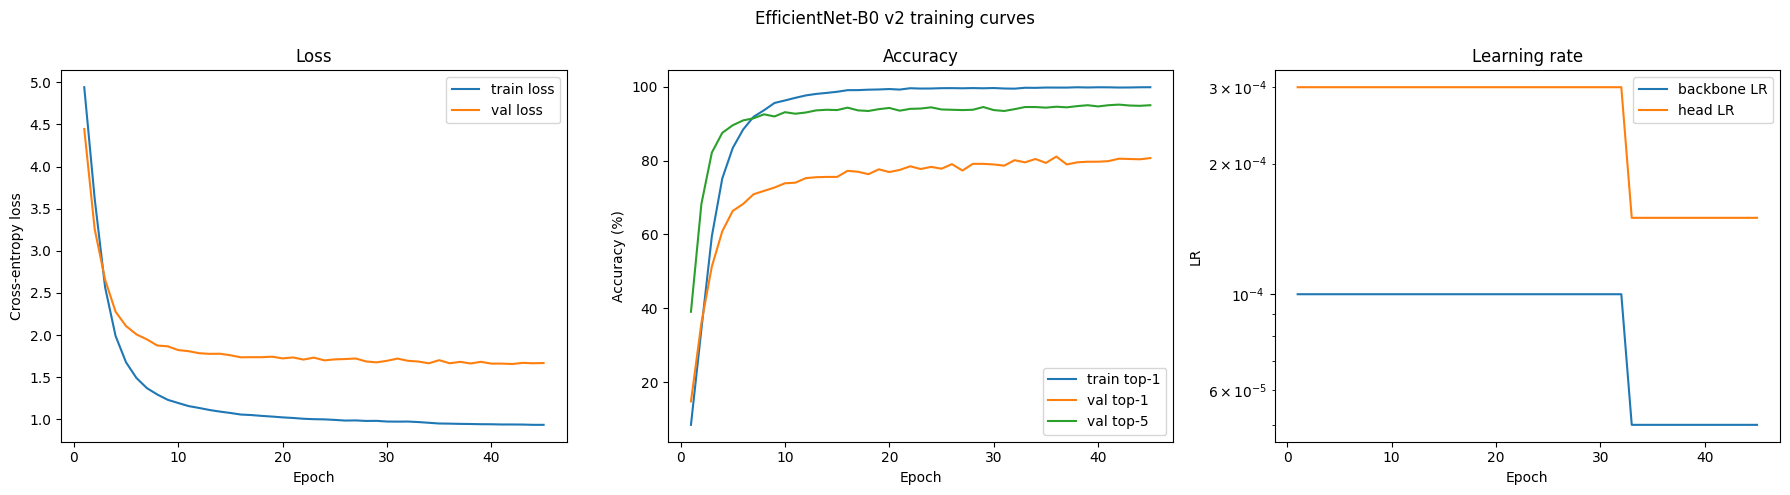

Saved curves to: /content/drive/MyDrive/twincar/models/efficientnet_b0_v2/training_curves.png


In [ ]:
history_df = pd.DataFrame(history)
history_df.insert(0, 'epoch', range(1, len(history_df) + 1))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(history_df['epoch'], history_df['train_loss'], label='train loss')
axes[0].plot(history_df['epoch'], history_df['val_loss'], label='val loss')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Cross-entropy loss')
axes[0].legend()

axes[1].plot(history_df['epoch'], history_df['train_top1'] * 100, label='train top-1')
axes[1].plot(history_df['epoch'], history_df['val_top1'] * 100, label='val top-1')
axes[1].plot(history_df['epoch'], history_df['val_top5'] * 100, label='val top-5')
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].legend()

axes[2].plot(history_df['epoch'], history_df['backbone_lr'], label='backbone LR')
axes[2].plot(history_df['epoch'], history_df['head_lr'], label='head LR')
axes[2].set_title('Learning rate')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('LR')
axes[2].set_yscale('log')
axes[2].legend()

plt.suptitle('EfficientNet-B0 v2 training curves')
plt.tight_layout()

curves_path = MODEL_DIR / 'training_curves.png'
plt.savefig(curves_path, dpi=150, bbox_inches='tight')
plt.show()

print('Saved curves to:', curves_path)

## 9. Final Test Evaluation

Now we load the best validation checkpoint and evaluate on the held-out test set.

Metrics included:

- test loss
- top-1 accuracy
- top-5 accuracy
- precision
- recall
- F1-score
- balanced accuracy
- make-level accuracy
- make + model accuracy, when metadata supports it

In [ ]:
def build_efficientnet_b0_v2(num_classes):
    m = models.efficientnet_b0(weights=None)
    in_features = m.classifier[1].in_features
    m.classifier = nn.Sequential(
        nn.Dropout(p=DROPOUT, inplace=True),
        nn.Linear(in_features, num_classes),
    )
    return m

best_model = build_efficientnet_b0_v2(NUM_CLASSES)
best_state = torch.load(MODEL_DIR / 'best_model.pt', map_location=DEVICE)
best_model.load_state_dict(best_state)
best_model = best_model.to(DEVICE)
best_model.eval()

print('Loaded best model from:', MODEL_DIR / 'best_model.pt')

Loaded best model from: /content/drive/MyDrive/twincar/models/efficientnet_b0_v2/best_model.pt


In [ ]:
def evaluate_model(model, loader, top_k=5):
    model.eval()
    criterion_eval = nn.CrossEntropyLoss()

    all_true = []
    all_pred = []
    all_conf = []
    all_topk = []
    total_loss = 0.0
    n_seen = 0

    start_time = time.time()

    with torch.inference_mode():
        for images, labels in tqdm(loader, desc='Evaluating test set'):
            images = images.to(DEVICE, non_blocking=True)
            labels = labels.to(DEVICE, non_blocking=True)

            with torch.amp.autocast('cuda', enabled=(DEVICE.type == 'cuda')):
                logits = model(images)
                loss = criterion_eval(logits, labels)

            probs = torch.softmax(logits, dim=1)
            conf, pred = probs.max(dim=1)
            topk = probs.topk(min(top_k, probs.size(1)), dim=1).indices

            batch_size = labels.size(0)
            total_loss += loss.item() * batch_size
            n_seen += batch_size

            all_true.extend(labels.cpu().numpy().tolist())
            all_pred.extend(pred.cpu().numpy().tolist())
            all_conf.extend(conf.cpu().numpy().tolist())
            all_topk.extend(topk.cpu().numpy().tolist())

    elapsed = time.time() - start_time

    return {
        'y_true': np.array(all_true),
        'y_pred': np.array(all_pred),
        'confidence': np.array(all_conf),
        'topk': np.array(all_topk),
        'test_loss': total_loss / n_seen,
        'elapsed_seconds': elapsed,
        'images_per_second': n_seen / elapsed if elapsed > 0 else None,
    }

results = evaluate_model(best_model, test_loader, top_k=TOP_K)

print(f"Test loss: {results['test_loss']:.4f}")
print(f"Evaluated {len(results['y_true'])} images in {results['elapsed_seconds']:.1f} seconds")
print(f"Speed: {results['images_per_second']:.2f} images/second")

Evaluating test set:   0%|          | 0/250 [00:00<?, ?it/s]

Test loss: 1.0310
Evaluated 8000 images in 67.4 seconds
Speed: 118.76 images/second


In [ ]:
y_true = results['y_true']
y_pred = results['y_pred']
topk = results['topk']

acc1 = accuracy_score(y_true, y_pred)
acc5 = np.mean([y_true[i] in topk[i] for i in range(len(y_true))])
bal_acc = balanced_accuracy_score(y_true, y_pred)

p_macro, r_macro, f_macro, _ = precision_recall_fscore_support(
    y_true, y_pred, average='macro', zero_division=0
)
p_weighted, r_weighted, f_weighted, _ = precision_recall_fscore_support(
    y_true, y_pred, average='weighted', zero_division=0
)

summary_metrics = pd.DataFrame([
    {'metric': 'test_loss', 'value': results['test_loss']},
    {'metric': 'top1_accuracy', 'value': acc1},
    {'metric': 'top5_accuracy', 'value': acc5},
    {'metric': 'balanced_accuracy', 'value': bal_acc},
    {'metric': 'macro_precision', 'value': p_macro},
    {'metric': 'macro_recall', 'value': r_macro},
    {'metric': 'macro_f1', 'value': f_macro},
    {'metric': 'weighted_precision', 'value': p_weighted},
    {'metric': 'weighted_recall', 'value': r_weighted},
    {'metric': 'weighted_f1', 'value': f_weighted},
])

summary_path = MODEL_DIR / 'test_summary_metrics.csv'
summary_metrics.to_csv(summary_path, index=False)

print(summary_metrics.to_string(index=False, formatters={'value': '{:.4f}'.format}))
print('Saved summary metrics to:', summary_path)

            metric  value
         test_loss 1.0310
     top1_accuracy 0.8164
     top5_accuracy 0.9450
 balanced_accuracy 0.8163
   macro_precision 0.8297
      macro_recall 0.8163
          macro_f1 0.8176
weighted_precision 0.8310
   weighted_recall 0.8164
       weighted_f1 0.8184
Saved summary metrics to: /content/drive/MyDrive/twincar/models/efficientnet_b0_v2/test_summary_metrics.csv


In [ ]:
idx_to_class = {idx: class_name for class_name, idx in test_dataset.class_to_idx.items()}
class_names = [idx_to_class[i] for i in range(NUM_CLASSES)]

report = classification_report(
    y_true,
    y_pred,
    labels=list(range(NUM_CLASSES)),
    target_names=class_names,
    zero_division=0,
    output_dict=True,
)

report_df = pd.DataFrame(report).transpose()
report_path = MODEL_DIR / 'classification_report.csv'
report_df.to_csv(report_path)
print('Saved classification report to:', report_path)

Saved classification report to: /content/drive/MyDrive/twincar/models/efficientnet_b0_v2/classification_report.csv


## 10. Aggregated Evaluation by Make and Make + Model

The full 195-class confusion matrix is hard to read. Predictions:

1. by **make**: BMW, Audi, Toyota, etc.
2. by **make + model** if the metadata has a `model` column; otherwise we fall back to the full class name.

In [ ]:
meta_unique = metadata.drop_duplicates(subset=['class_name']).copy()
meta_unique['sanitized'] = meta_unique['class_name'].apply(sanitize)

sanitized_to_make = dict(zip(meta_unique['sanitized'], meta_unique['make'])) if 'make' in meta_unique.columns else {}

if 'model' in meta_unique.columns:
    meta_unique['make_model'] = meta_unique['make'].astype(str) + ' ' + meta_unique['model'].astype(str)
else:
    # Fallback: use full class name. This is less aggregated, but still valid.
    meta_unique['make_model'] = meta_unique['class_name'].astype(str)

sanitized_to_make_model = dict(zip(meta_unique['sanitized'], meta_unique['make_model']))

idx_to_make = {
    idx: sanitized_to_make.get(class_name, class_name.split('_')[0])
    for idx, class_name in idx_to_class.items()
}

idx_to_make_model = {
    idx: sanitized_to_make_model.get(class_name, class_name)
    for idx, class_name in idx_to_class.items()
}

true_make = np.array([idx_to_make[i] for i in y_true])
pred_make = np.array([idx_to_make[i] for i in y_pred])
true_make_model = np.array([idx_to_make_model[i] for i in y_true])
pred_make_model = np.array([idx_to_make_model[i] for i in y_pred])

make_acc = accuracy_score(true_make, pred_make)
make_model_acc = accuracy_score(true_make_model, pred_make_model)

print(f'Make accuracy       : {make_acc * 100:.2f}%')
print(f'Make+model accuracy : {make_model_acc * 100:.2f}%')

Make accuracy       : 88.81%
Make+model accuracy : 82.19%


In [ ]:
def per_group_metrics(y_true_group, y_pred_group, group_name):
    labels = sorted(set(y_true_group) | set(y_pred_group))
    p, r, f1, support = precision_recall_fscore_support(
        y_true_group,
        y_pred_group,
        labels=labels,
        zero_division=0,
    )
    df = pd.DataFrame({
        group_name: labels,
        'precision': p,
        'recall': r,
        'f1': f1,
        'support': support,
    }).sort_values('f1', ascending=False).reset_index(drop=True)
    return df

per_make = per_group_metrics(true_make, pred_make, 'make')
per_make_model = per_group_metrics(true_make_model, pred_make_model, 'make_model')

per_make_path = MODEL_DIR / 'per_make_metrics.csv'
per_make_model_path = MODEL_DIR / 'per_make_model_metrics.csv'

per_make.to_csv(per_make_path, index=False)
per_make_model.to_csv(per_make_model_path, index=False)

print('Saved:', per_make_path)
print('Saved:', per_make_model_path)
print('\nWorst 10 makes by F1:')
print(per_make.tail(10).to_string(index=False, formatters={
    'precision': '{:.3f}'.format,
    'recall': '{:.3f}'.format,
    'f1': '{:.3f}'.format,
}))

Saved: /content/drive/MyDrive/twincar/models/efficientnet_b0_v2/per_make_metrics.csv
Saved: /content/drive/MyDrive/twincar/models/efficientnet_b0_v2/per_make_model_metrics.csv

Worst 10 makes by F1:
   make precision recall    f1  support
Lincoln     0.938  0.769 0.845       39
  Mazda     0.756  0.944 0.840       36
 Daewoo     0.784  0.889 0.833       45
Maybach     0.750  0.931 0.831       29
  Isuzu     0.766  0.900 0.828       40
 Fisker     0.683  0.953 0.796       43
 Jaguar     0.771  0.804 0.787       46
 Spyker     0.787  0.724 0.754       87
Porsche     0.661  0.860 0.747       43
  Tesla     0.437  1.000 0.608       38


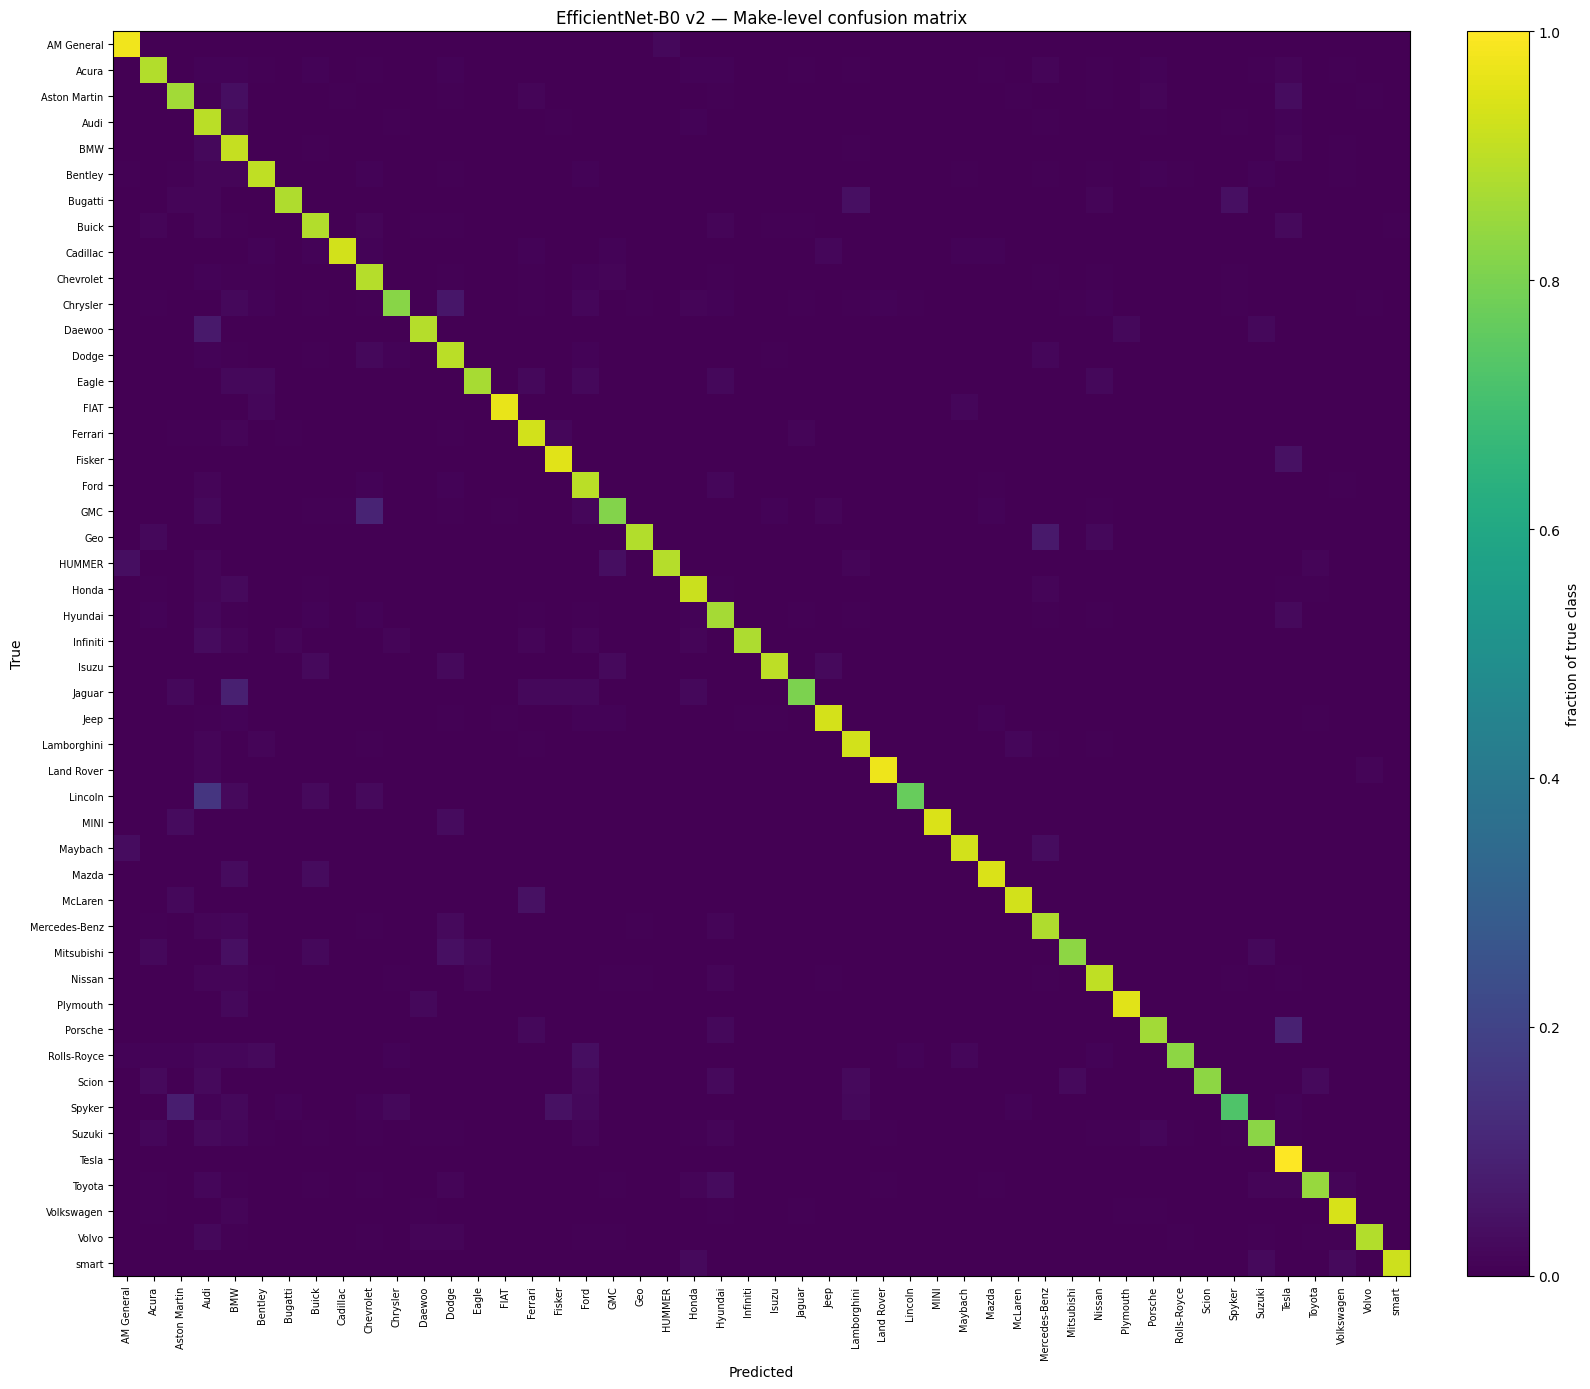

Saved confusion matrix to: /content/drive/MyDrive/twincar/models/efficientnet_b0_v2/confusion_matrix_make.png


In [ ]:
def plot_confusion_matrix(y_true_group, y_pred_group, labels, title, output_path, figsize=(14, 12)):
    cm = confusion_matrix(y_true_group, y_pred_group, labels=labels)
    row_sums = cm.sum(axis=1, keepdims=True)
    cm_norm = np.divide(cm, row_sums, out=np.zeros_like(cm, dtype=float), where=row_sums != 0)

    fig, ax = plt.subplots(figsize=figsize)
    im = ax.imshow(cm_norm, aspect='auto', vmin=0, vmax=1)
    ax.set_xticks(range(len(labels)))
    ax.set_yticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=90, fontsize=7)
    ax.set_yticklabels(labels, fontsize=7)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    ax.set_title(title)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='fraction of true class')
    plt.tight_layout()
    plt.savefig(output_path, dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved confusion matrix to:', output_path)

# Make-level confusion matrix: readable because there are far fewer makes than classes.
make_labels = sorted(set(true_make) | set(pred_make))
plot_confusion_matrix(
    true_make,
    pred_make,
    make_labels,
    'EfficientNet-B0 v2 - Make-level confusion matrix',
    MODEL_DIR / 'confusion_matrix_make.png',
    figsize=(16, 14),
)

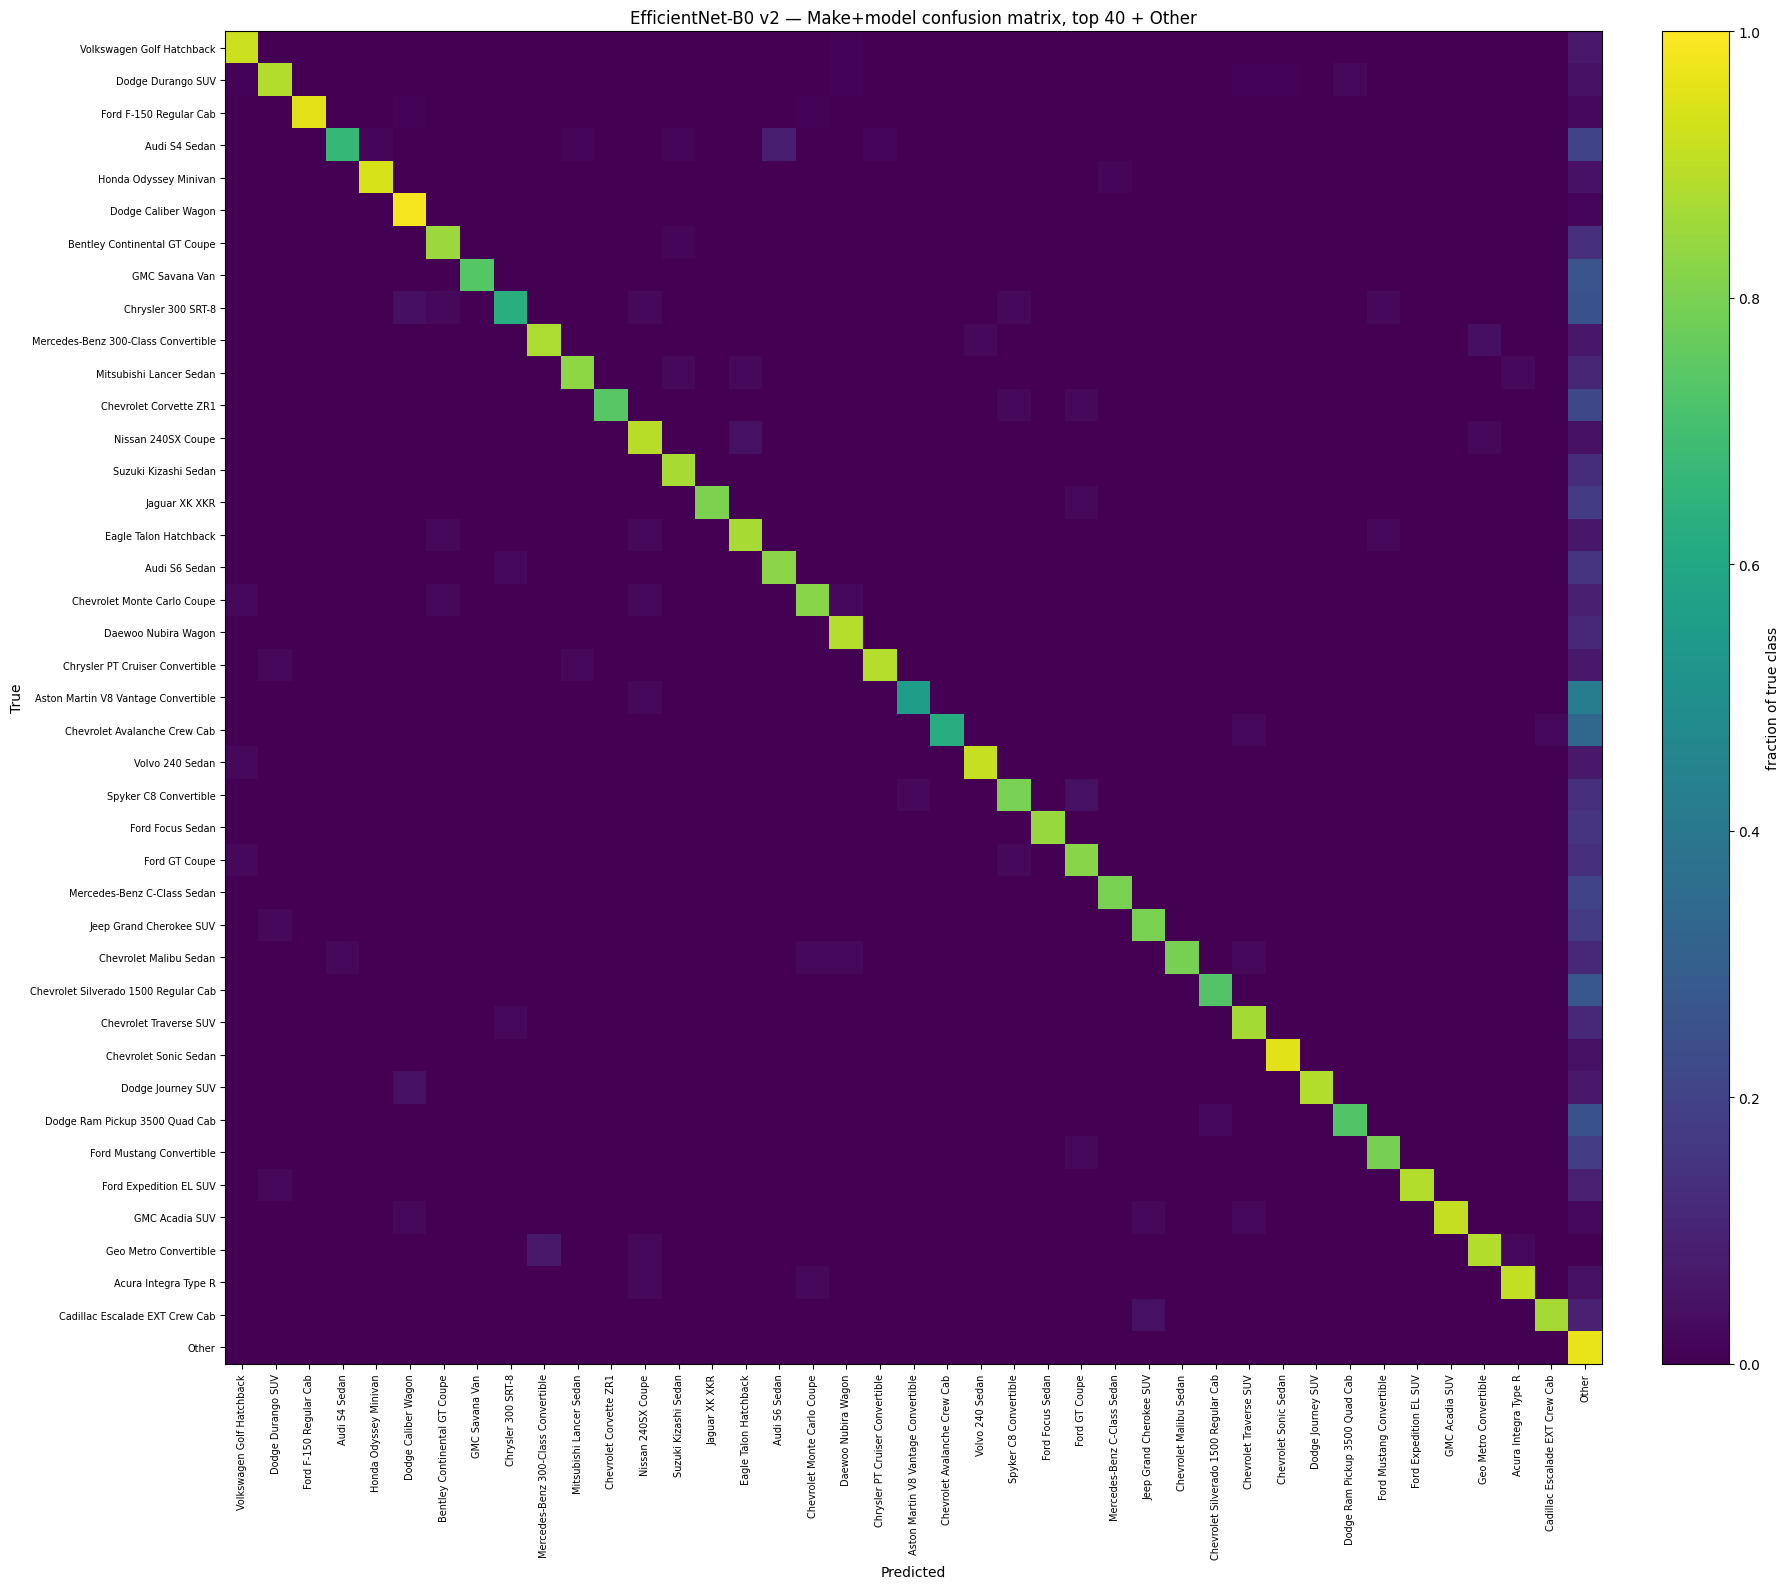

Saved confusion matrix to: /content/drive/MyDrive/twincar/models/efficientnet_b0_v2/confusion_matrix_make_model_top40.png


In [ ]:
# Make+model confusion matrix can still be large.
# To keep it readable, we show the top N most frequent make+model labels and group the rest as Other.
TOP_N_MAKE_MODEL = 40

top_make_models = pd.Series(true_make_model).value_counts().head(TOP_N_MAKE_MODEL).index.tolist()

def restrict_to_top(labels_array, top_labels):
    return np.array([label if label in top_labels else 'Other' for label in labels_array])

true_mm_small = restrict_to_top(true_make_model, top_make_models)
pred_mm_small = restrict_to_top(pred_make_model, top_make_models)
mm_labels = top_make_models + ['Other']

plot_confusion_matrix(
    true_mm_small,
    pred_mm_small,
    mm_labels,
    f'EfficientNet-B0 v2 - Make+model confusion matrix, top {TOP_N_MAKE_MODEL} + Other',
    MODEL_DIR / 'confusion_matrix_make_model_top40.png',
    figsize=(18, 16),
)

In [ ]:
def top_confused_pairs(y_true_group, y_pred_group, output_path, top_n=30):
    labels = sorted(set(y_true_group) | set(y_pred_group))
    cm = confusion_matrix(y_true_group, y_pred_group, labels=labels)

    pairs = []
    for i, true_label in enumerate(labels):
        row_total = cm[i].sum()
        for j, pred_label in enumerate(labels):
            if i == j or cm[i, j] == 0:
                continue
            pairs.append({
                'true_label': true_label,
                'predicted_label': pred_label,
                'count': int(cm[i, j]),
                'pct_of_true': cm[i, j] / row_total if row_total else 0,
            })

    df = pd.DataFrame(pairs).sort_values('count', ascending=False).reset_index(drop=True)
    df.to_csv(output_path, index=False)
    print(f'Saved confused pairs to: {output_path}')
    return df.head(top_n)

print('Top confused make pairs:')
display(top_confused_pairs(true_make, pred_make, MODEL_DIR / 'top_confused_make_pairs.csv', top_n=20))

print('\nTop confused make+model pairs:')
display(top_confused_pairs(true_make_model, pred_make_model, MODEL_DIR / 'top_confused_make_model_pairs.csv', top_n=20))

Top confused make pairs:
Saved confused pairs to: /content/drive/MyDrive/twincar/models/efficientnet_b0_v2/top_confused_make_pairs.csv


,true_label,predicted_label,count,pct_of_true
0,GMC,Chevrolet,23,0.097872
1,Audi,BMW,15,0.025862
2,Chrysler,Dodge,15,0.058594
3,Dodge,Chevrolet,13,0.020867
4,Chevrolet,GMC,12,0.013423
5,BMW,Audi,11,0.020992
6,Dodge,Mercedes-Benz,11,0.017657
7,Hyundai,Tesla,11,0.025404
8,Ford,Hyundai,9,0.017510
9,Hyundai,Audi,8,0.018476



Top confused make+model pairs:
Saved confused pairs to: /content/drive/MyDrive/twincar/models/efficientnet_b0_v2/top_confused_make_model_pairs.csv


,true_label,predicted_label,count,pct_of_true
0,Chevrolet Express Van,Chevrolet Express Cargo Van,17,0.485714
1,Chevrolet Silverado 1500 Hybrid Crew Cab,Chevrolet Silverado 1500 Extended Cab,11,0.275000
2,BMW 6 Series Convertible,BMW M6 Convertible,10,0.227273
3,Audi S5 Coupe,Audi A5 Coupe,10,0.238095
4,Ferrari 458 Italia Convertible,Ferrari 458 Italia Coupe,10,0.256410
5,Audi TTS Coupe,Audi TT Hatchback,9,0.214286
6,Audi V8 Sedan,Audi 100 Sedan,9,0.209302
7,Dodge Sprinter Cargo Van,Mercedes-Benz Sprinter Van,9,0.230769
8,Bentley Continental Flying Spur Sedan,Bentley Continental GT Coupe,9,0.204545
9,Audi 100 Sedan,Audi 100 Wagon,8,0.200000


## 11. Save Per-Image Predictions

In [ ]:
image_paths = [path for path, _ in test_dataset.samples]

predictions_df = pd.DataFrame({
    'image_path': image_paths,
    'true_idx': y_true,
    'pred_idx': y_pred,
    'true_class': [idx_to_class[i] for i in y_true],
    'pred_class': [idx_to_class[i] for i in y_pred],
    'true_make': true_make,
    'pred_make': pred_make,
    'true_make_model': true_make_model,
    'pred_make_model': pred_make_model,
    'confidence': results['confidence'],
    'correct': y_true == y_pred,
})

predictions_path = MODEL_DIR / 'test_predictions.csv'
predictions_df.to_csv(predictions_path, index=False)

print('Saved predictions to:', predictions_path)
print('\nLowest-confidence wrong predictions:')
display(predictions_df[predictions_df['correct'] == False].sort_values('confidence').head(10))

Saved predictions to: /content/drive/MyDrive/twincar/models/efficientnet_b0_v2/test_predictions.csv

Lowest-confidence wrong predictions:


,image_path,true_idx,pred_idx,true_class,pred_class,true_make,pred_make,true_make_model,pred_make_model,confidence,correct
6921,/content/twincar_data/test/Nissan_Juke_Hatchba...,168,80,Nissan_Juke_Hatchback_2012,Chrysler_Town_and_Country_Minivan_2012,Nissan,Chrysler,Nissan Juke Hatchback,Chrysler Town and Country Minivan,0.026245,False
2256,/content/twincar_data/test/Chevrolet_Cobalt_SS...,55,164,Chevrolet_Cobalt_SS_2010,Mercedes-Benz_SL-Class_Coupe_2009,Chevrolet,Mercedes-Benz,Chevrolet Cobalt SS,Mercedes-Benz SL-Class Coupe,0.030334,False
5300,/content/twincar_data/test/Honda_Odyssey_Miniv...,128,161,Honda_Odyssey_Minivan_2012,Mercedes-Benz_C-Class_Sedan_2012,Honda,Mercedes-Benz,Honda Odyssey Minivan,Mercedes-Benz C-Class Sedan,0.032288,False
1829,/content/twincar_data/test/Bugatti_Veyron_16.4...,45,44,Bugatti_Veyron_16.4_Coupe_2009,Bugatti_Veyron_16.4_Convertible_2009,Bugatti,Bugatti,Bugatti Veyron 16.4 Coupe,Bugatti Veyron 16.4 Convertible,0.039398,False
401,/content/twincar_data/test/Aston_Martin_Virage...,9,50,Aston_Martin_Virage_Convertible_2012,Cadillac_CTS-V_Sedan_2012,Aston Martin,Cadillac,Aston Martin Virage Convertible,Cadillac CTS-V Sedan,0.039612,False
7286,/content/twincar_data/test/Spyker_C8_Convertib...,177,114,Spyker_C8_Convertible_2009,Ford_GT_Coupe_2006,Spyker,Ford,Spyker C8 Convertible,Ford GT Coupe,0.041504,False
331,/content/twincar_data/test/Aston_Martin_V8_Van...,8,29,Aston_Martin_V8_Vantage_Coupe_2012,BMW_6_Series_Convertible_2007,Aston Martin,BMW,Aston Martin V8 Vantage Coupe,BMW 6 Series Convertible,0.041534,False
1958,/content/twincar_data/test/Buick_Regal_GS_2012...,48,6,Buick_Regal_GS_2012,Acura_ZDX_Hatchback_2012,Buick,Acura,Buick Regal GS,Acura ZDX Hatchback,0.042542,False
3739,/content/twincar_data/test/Dodge_Durango_SUV_2...,91,25,Dodge_Durango_SUV_2012,BMW_1_Series_Convertible_2012,Dodge,BMW,Dodge Durango SUV,BMW 1 Series Convertible,0.043060,False
173,/content/twincar_data/test/Acura_TL_Type-S_200...,4,21,Acura_TL_Type-S_2008,Audi_TTS_Coupe_2012,Acura,Audi,Acura TL Type-S,Audi TTS Coupe,0.044495,False


## 12. Final Summary

In [ ]:
model_file = MODEL_DIR / 'best_model.pt'
model_size_mb = model_file.stat().st_size / 1e6 if model_file.exists() else None

print('EfficientNet-B0 v2 summary')
print('=' * 40)
print(f'Best model path      : {model_file}')
print(f'Model file size      : {model_size_mb:.2f} MB' if model_size_mb else 'Model file not found')
print(f'Best validation top1 : {history["val_top1"][best_idx] * 100:.2f}%')
print(f'Test loss            : {results["test_loss"]:.4f}')
print(f'Test top1 accuracy   : {acc1 * 100:.2f}%')
print(f'Test top5 accuracy   : {acc5 * 100:.2f}%')
print(f'Macro precision      : {p_macro:.4f}')
print(f'Macro recall         : {r_macro:.4f}')
print(f'Macro F1             : {f_macro:.4f}')
print(f'Weighted F1          : {f_weighted:.4f}')
print(f'Make accuracy        : {make_acc * 100:.2f}%')
print(f'Make+model accuracy  : {make_model_acc * 100:.2f}%')
print()
print('Artifacts saved in:', MODEL_DIR)
for path in sorted(MODEL_DIR.iterdir()):
    if path.is_file():
        print(' -', path.name)

EfficientNet-B0 v2 summary
Best model path      : /content/drive/MyDrive/twincar/models/efficientnet_b0_v2/best_model.pt
Model file size      : 17.33 MB
Best validation top1 : 80.51%
Test loss            : 1.0310
Test top1 accuracy   : 81.64%
Test top5 accuracy   : 94.50%
Macro precision      : 0.8297
Macro recall         : 0.8163
Macro F1             : 0.8176
Weighted F1          : 0.8184
Make accuracy        : 88.81%
Make+model accuracy  : 82.19%

Artifacts saved in: /content/drive/MyDrive/twincar/models/efficientnet_b0_v2
 - best_model.pt
 - class_to_idx.json
 - classification_report.csv
 - confusion_matrix_make.png
 - confusion_matrix_make_model_top40.png
 - idx_to_class.json
 - last_checkpoint.pt
 - per_make_metrics.csv
 - per_make_model_metrics.csv
 - test_predictions.csv
 - test_summary_metrics.csv
 - top_confused_make_model_pairs.csv
 - top_confused_make_pairs.csv
 - train_config.json
 - training_curves.png
 - training_history.csv
